**Import Libraries**


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Read Data**

In [3]:
data=pd.read_csv('/content/ds_salaries.csv')
data

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


**Data Cleaning & Pre Processing**

In [4]:
data.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [5]:
data.shape

(3755, 11)

In [6]:
data.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [7]:
data=data.drop(columns=["salary","salary_currency"])

In [8]:
data[data.duplicated(keep=False)]
data = data.drop_duplicates().reset_index(drop=True)

In [9]:
data['experience_level'] = data['experience_level'].replace({
    'EN': 'Entry-level',
    'MI': 'Mid-level',
    'SE': 'Senior-level',
    'EX': 'Executive-level'
})
data['employment_type'] = data['employment_type'].replace({
    'FT': 'Full-time',
    'PT': 'Part-time',
    'CT': 'Contract',
    'FL': 'Freelance'
})
data['company_size'] = data['company_size'].replace({
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
})
data['remote_ratio'] = data['remote_ratio'].replace({
    0: 'On-site',
    50: 'Hybrid',
    100: 'Remote'
})

data[['employee_residence','company_location']]=data[['employee_residence','company_location']].replace({
    'US': 'United States',
    'CA': 'Canada',
    'DE': 'Germany',
    'GB': 'United Kingdom',
    'IN': 'India',
    'ES': 'Spain',
    'NG': 'Nigeria',
    'HK': 'Hong Kong',
    'NL': 'Netherlands',
    'CH': 'Switzerland',
    'CF': 'Central African Republic',
    'FR': 'France',
    'FI': 'Finland',
    'UA': 'Ukraine',
    'IE': 'Ireland',
    'IL': 'Israel',
    'GH': 'Ghana',
    'CO': 'Colombia',
    'SG': 'Singapore',
    'AU': 'Australia',
    'SE': 'Sweden',
    'SI': 'Slovenia',
    'MX': 'Mexico',
    'BR': 'Brazil',
    'PT': 'Portugal',
    'RU': 'Russia',
    'TH': 'Thailand',
    'HR': 'Croatia',
    'VN': 'Vietnam',
    'EE': 'Estonia',
    'AM': 'Armenia',
    'BA': 'Bosnia and Herzegovina',
    'KE': 'Kenya',
    'GR': 'Greece',
    'MK': 'North Macedonia',
    'LV': 'Latvia',
    'RO': 'Romania',
    'PK': 'Pakistan',
    'IT': 'Italy',
    'MA': 'Morocco',
    'PL': 'Poland',
    'AL': 'Albania',
    'AR': 'Argentina',
    'LT': 'Lithuania',
    'AS': 'American Samoa',
    'CR': 'Costa Rica',
    'IR': 'Iran',
    'BS': 'Bahamas',
    'HU': 'Hungary',
    'AT': 'Austria',
    'SK': 'Slovakia',
    'CZ': 'Czech Republic',
    'TR': 'Turkey',
    'PR': 'Puerto Rico',
    'DK': 'Denmark',
    'BO': 'Bolivia',
    'PH': 'Philippines',
    'BE': 'Belgium',
    'ID': 'Indonesia',
    'EG': 'Egypt',
    'AE': 'United Arab Emirates',
    'LU': 'Luxembourg',
    'MY': 'Malaysia',
    'HN': 'Honduras',
    'JP': 'Japan',
    'DZ': 'Algeria',
    'IQ': 'Iraq',
    'CN': 'China',
    'NZ': 'New Zealand',
    'CL': 'Chile',
    'MD': 'Moldova',
    'MT': 'Malta'
})


In [10]:
data = data.rename(columns={
    'salary_in_usd': 'salary'
})


In [11]:
bins = [0,25000, 50000, 100000, 150000, 200000, data['salary'].max()]
labels = ['<25K','25K-50K', '50K–100K', '100K–150K', '150K–200K', '200K+']

data['salary_range'] = pd.cut(
    data['salary'],
    bins=bins,
    labels=labels
)

data['salary_range'].value_counts()


,count
salary_range,
100K–150K,788
50K–100K,611
150K–200K,553
200K+,376
25K-50K,155
<25K,101


In [12]:
data['employment_type'].value_counts()

,count
employment_type,
Full-time,2547
Part-time,17
Contract,10
Freelance,10


In [13]:
data['company_size'].value_counts()

,count
company_size,
Medium,2028
Large,409
Small,147


In [14]:
data['experience_level'].value_counts()

,count
experience_level,
Senior-level,1554
Mid-level,664
Entry-level,270
Executive-level,96


In [15]:
data['work_year'].value_counts()

,count
work_year,
2023,1156
2022,1125
2021,228
2020,75


In [16]:
data['remote_ratio'].value_counts()

,count
remote_ratio,
Remote,1211
On-site,1186
Hybrid,187


**Data Analysis**

# **📊 Salary Distribution with Outliers**

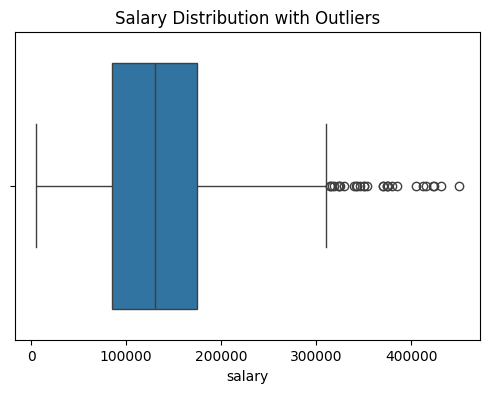

In [17]:

plt.figure(figsize=(6,4))
sns.boxplot(x=data['salary'])
plt.title('Salary Distribution with Outliers')
plt.show()

**Insight**

**“The salary distribution shows a small number of extremely high-paying roles, highlighting how specialized expertise and leadership positions command premium compensation.”**

# **📊 Salary Range Distribution with Outliers**

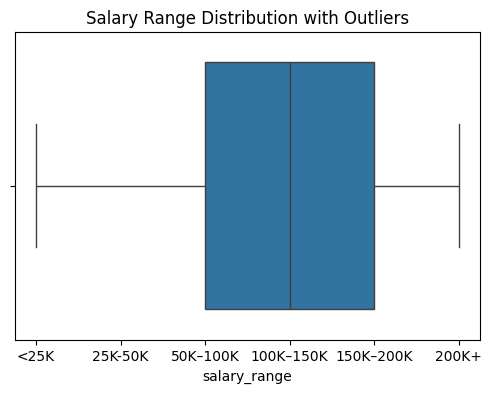

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['salary_range'])
plt.title('Salary Range Distribution with Outliers')
plt.show()


**Insight**

**“Salary range analysis shows most roles clustered in mid-level pay bands, with a small number of high-paying outliers reflecting premium positions.”**

# **📈  Salary vs Work Year**

In [19]:
yearly_salary=(data.groupby('work_year')['salary']
               .median()
               .reset_index()
               .sort_values('salary')
              )

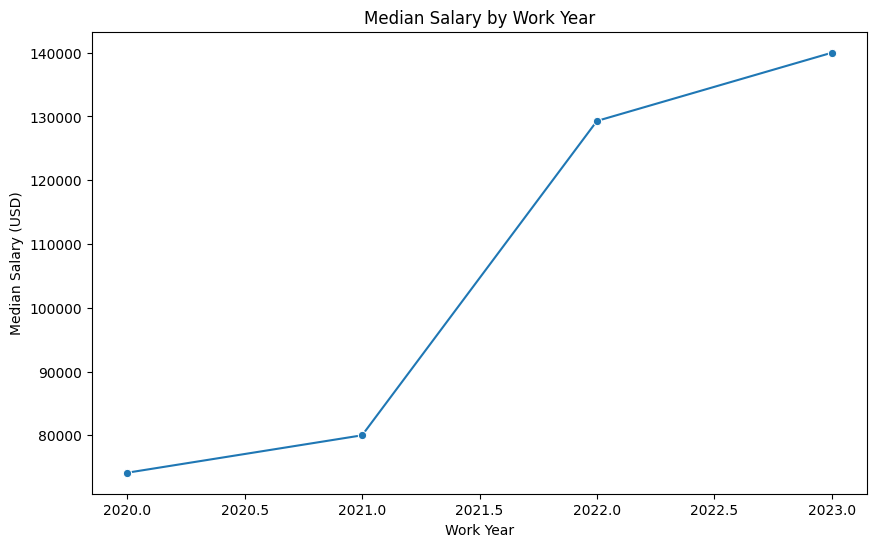

In [20]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=yearly_salary,
    x='work_year',
    y='salary',
    marker='o'

)
plt.title('Median Salary by Work Year')
plt.xlabel('Work Year')
plt.ylabel('Median Salary (USD)')
plt.show()

**Insight**

**“Data Science salaries have increased significantly over time, with the strongest growth occurring after 2021 as demand for data expertise accelerated.”**

In [21]:
pd.crosstab(data['work_year'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
work_year,,,,,,
2020,11,14,23,19,3,5
2021,35,31,83,38,27,14
2022,38,73,275,354,249,136
2023,17,37,230,377,274,221


# **📊 Salary vs Experience Level**

In [22]:
exp_salary = (
    data.groupby('experience_level')['salary']
    .median()
    .reset_index()
    .sort_values('salary')
)


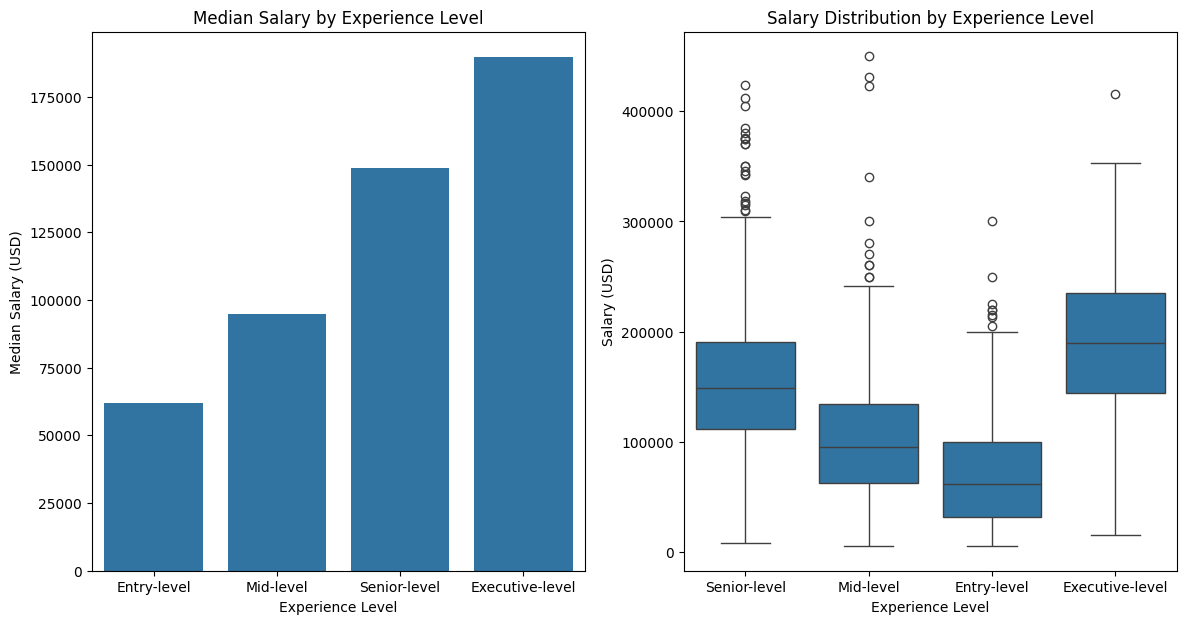

In [23]:
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.barplot(
    data=exp_salary,
    x='experience_level',
    y='salary'
)
plt.title('Median Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Median Salary (USD)')

plt.subplot(1, 2, 2)
sns.boxplot(
    data=data,
    x='experience_level',
    y='salary'
)

plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

**Insight**

**“Salary increases significantly with experience level, and compensation variability grows at senior and executive stages due to role specialization and leadership impact.”**

In [24]:
pd.crosstab(data['experience_level'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
experience_level,,,,,,
Entry-level,53,54,103,40,12,8
Executive-level,1,0,6,22,30,37
Mid-level,38,68,263,191,78,26
Senior-level,9,33,239,535,433,305


# **📊 Remote Ratio vs Salary**




In [25]:
remote_salary=(data.groupby('remote_ratio')['salary']
               .median()
               .reset_index()
               .sort_values('salary'))


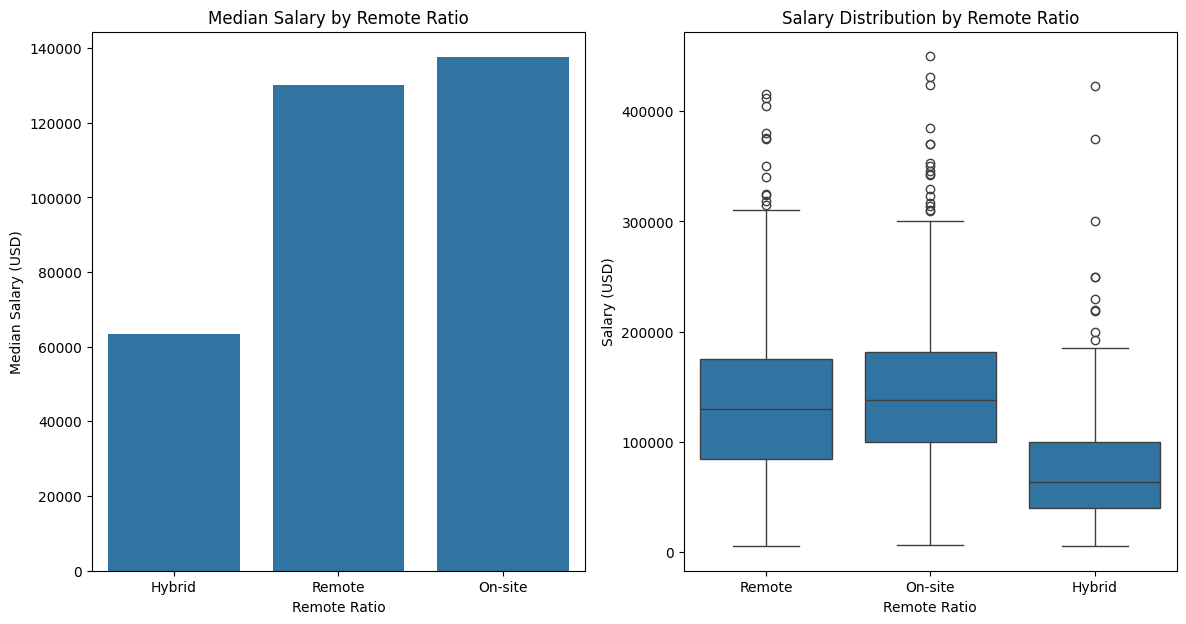

In [26]:
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.barplot(
    data=remote_salary,
    x='remote_ratio',
    y='salary'
)

plt.title('Median Salary by Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Median Salary (USD)')

plt.subplot(1, 2, 2)
sns.boxplot(
    data=data,
    x='remote_ratio',
    y='salary'
)

plt.title('Salary Distribution by Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary (USD)')
plt.show()

**Insight:**

**"Fully remote and on-site jobs generally pay more than hybrid roles, and both also show a wider range of salaries, meaning top earners are more likely to be found in fully remote or fully on-site positions."**

In [27]:
pd.crosstab(data['remote_ratio'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
remote_ratio,,,,,,
Hybrid,30,36,75,30,8,8
On-site,21,36,250,405,264,210
Remote,50,83,286,353,281,158


# **📊 Employment Type vs Salary**

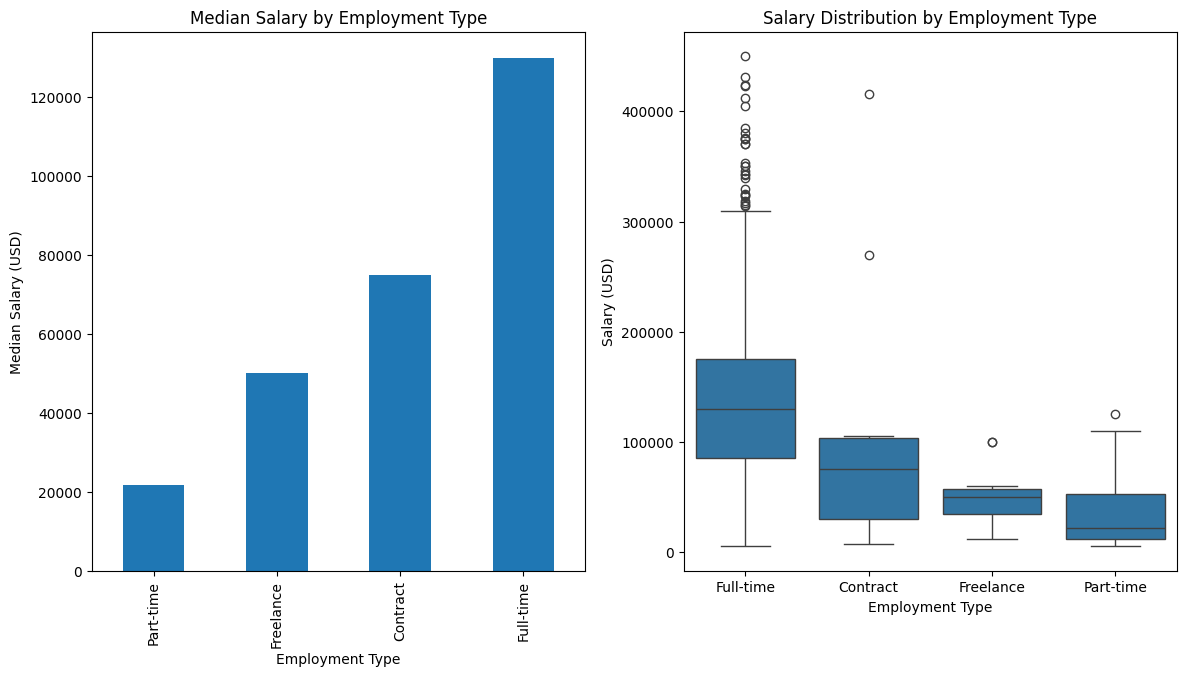

In [28]:
employment_salary = (
    data.groupby('employment_type')['salary']
    .median()
    .sort_values()
)

plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
employment_salary.plot(kind='bar')
plt.title('Median Salary by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Median Salary (USD)')
plt.subplot(1,2,2)
sns.boxplot(
    data=data,
    x='employment_type',
    y='salary'
)

plt.title('Salary Distribution by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Salary (USD)')
plt.show()


**Insight:**

**Full-time roles offer the highest and most stable salaries, while part-time roles pay the least and show the most variation.**

In [29]:
pd.crosstab(data['employment_type'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
employment_type,,,,,,
Contract,1,3,3,1,0,2
Freelance,2,5,3,0,0,0
Full-time,89,144,602,785,553,374
Part-time,9,3,3,2,0,0


# **📊 Company Size vs Salary**

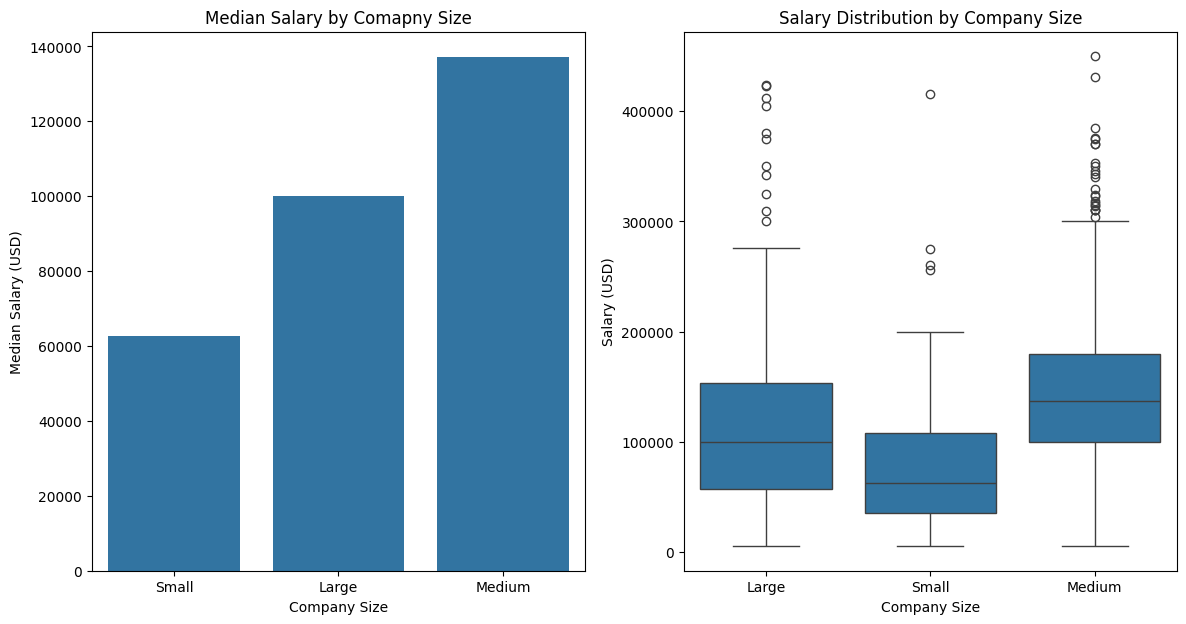

In [30]:
salary_company_size=(
    data.groupby('company_size')['salary']
    .median()
    .reset_index()
    .sort_values('salary')
)

plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
sns.barplot(
    data=salary_company_size,
    x='company_size',
    y='salary'
)
plt.title('Median Salary by Comapny Size')
plt.xlabel('Company Size')
plt.ylabel('Median Salary (USD)')
plt.subplot(1,2,2)
sns.boxplot(
    data=data,
    x='company_size',
    y='salary'
)

plt.title('Salary Distribution by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary (USD)')
plt.show()

**Insight:**

**Medium and large companies pay higher salaries than small companies, with medium companies offering the best balance.**

In [31]:
pd.crosstab(data['company_size'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
company_size,,,,,,
Large,41,44,120,96,60,48
Medium,36,81,438,668,481,324
Small,24,30,53,24,12,4


# **🎯Remote Ratio & Experience Level (%)**

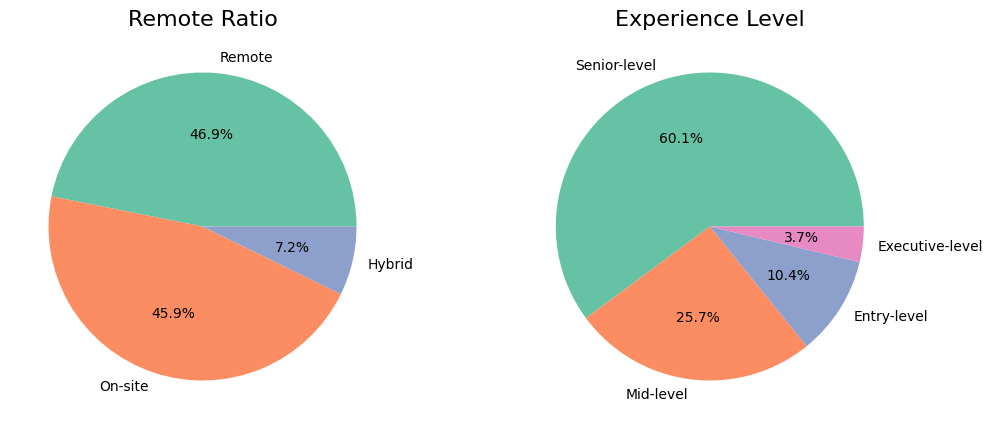

In [32]:
plt.figure(figsize=(12, 5))
sns.set_palette('Set2')

# job types
plt.subplot(1,2,1)
ax = data['remote_ratio'].value_counts().plot(kind='pie', autopct='%1.1f%%')
ax.set_title('Remote Ratio', fontdict={'fontsize': 16})
ax.set_ylabel('')

# experience levels
plt.subplot(1,2,2)
ax = data['experience_level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
ax.set_title('Experience Level', fontdict={'fontsize': 16})
ax.set_ylabel('')
plt.show()

**Insight 1:**

**Most jobs are either fully remote or fully on-site, while hybrid roles are very limited.**


**Insight 2:**

**The workforce is dominated by senior professionals, while entry-level and executive roles make up a much smaller share.**

# **📊 Top 10 Job Roles with Highest Paying**

In [33]:
job_salary = (
    data.groupby('job_title')['salary']
    .median()
    .sort_values(ascending=False)
)
top_10_jobs = job_salary.head(10)
top_roles=data['job_title'].value_counts().head(10)

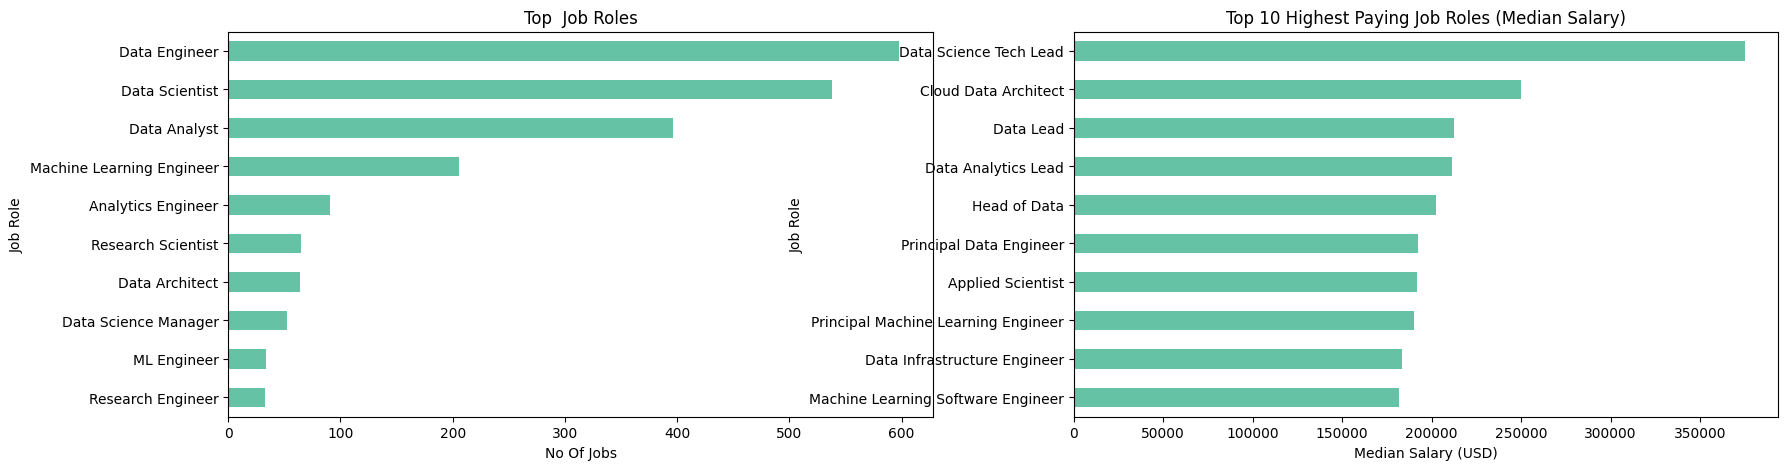

In [34]:
salary_company_size=(
    data.groupby('company_size')['salary']
    .median()
    .reset_index()
    .sort_values('salary')
)

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
top_roles.sort_values().plot(kind='barh')

plt.title('Top  Job Roles')
plt.xlabel('No Of Jobs')
plt.ylabel('Job Role')
plt.subplot(1,2,2)
top_10_jobs.sort_values().plot(kind='barh')

plt.title('Top 10 Highest Paying Job Roles (Median Salary)')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Job Role')
plt.show()

*Top Job Roles by Number of Jobs*

**Insight:**

**Data Engineer and Data Scientist roles dominate the job market, while research-focused and niche roles have much lower demand.**

*Top 10 Highest Paying Job Roles*

**Insight:**

**Leadership and specialized architecture roles command the highest salaries, even though they appear far less frequently in the job market.**

In [35]:
pd.crosstab(data['job_title'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
job_title,,,,,,
3D Computer Vision Researcher,3,1,0,0,0,0
AI Developer,1,0,4,2,1,3
AI Programmer,0,1,1,0,0,0
AI Scientist,3,5,1,2,4,1
Analytics Engineer,1,2,10,37,26,15
...,...,...,...,...,...,...
Research Engineer,0,0,4,12,9,8
Research Scientist,1,2,16,21,11,14
Software Data Engineer,0,1,1,0,0,0


# **📊 Top 10 Company Locations by Jobs & Salary**

In [36]:
salary_company_location=(
    data.groupby('company_location')['salary']
    .median()
    .reset_index()
   .sort_values('salary',ascending=False)
)
top_10_countries=salary_company_location.head(10)
top_countries=data['company_location'].value_counts().head(10)

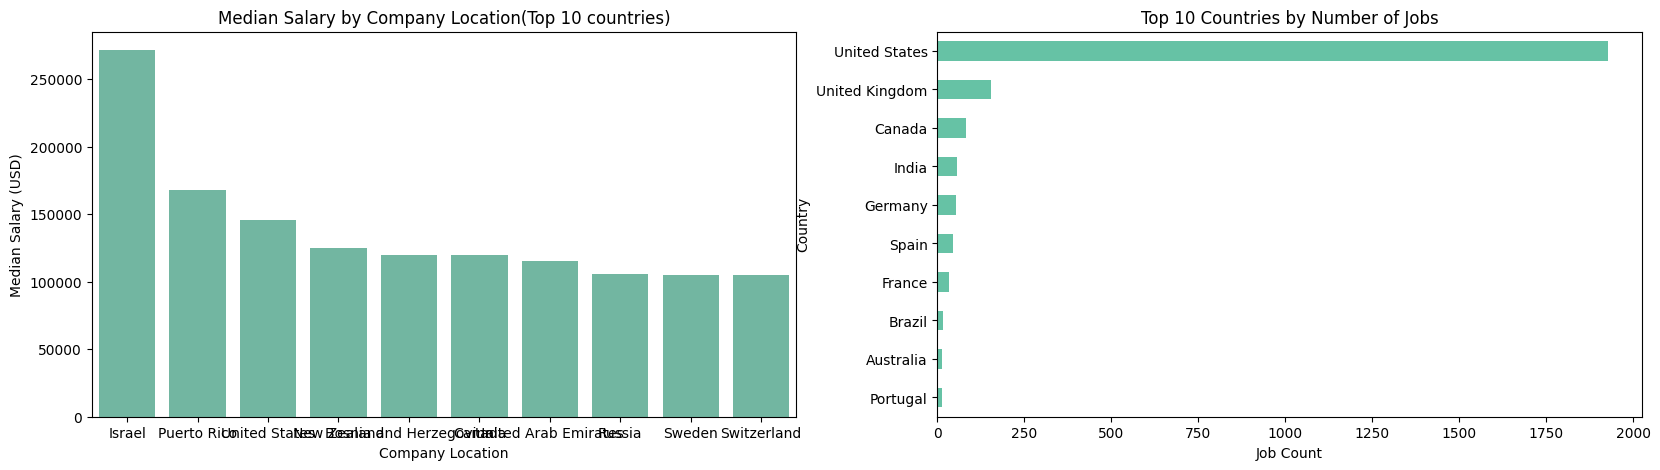

In [37]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.barplot(
    data=top_10_countries,
    x='company_location',
    y='salary'
)

plt.title('Median Salary by Company Location(Top 10 countries)')
plt.xlabel('Company Location')
plt.ylabel('Median Salary (USD)')
plt.subplot(1,2,2)

top_countries.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Number of Jobs')
plt.xlabel('Job Count')
plt.ylabel('Country')
plt.show()

*Salary by Company Location (Top 10 Countries)*

**Insight:**

**Some countries offer very high salaries despite having fewer jobs, showing they pay more to attract specialized talent.**

*Top 10 Countries by Number of Jobs*


**Insight:**

**The United States dominates job availability, while most other countries have significantly fewer openings.**


In [38]:
pd.crosstab(data['company_location'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
company_location,,,,,,
Albania,1,0,0,0,0,0
Algeria,0,0,1,0,0,0
American Samoa,2,1,0,0,0,0
Argentina,2,1,0,0,0,0
Armenia,0,1,0,0,0,0
...,...,...,...,...,...,...
Ukraine,1,1,1,1,0,0
United Arab Emirates,0,0,1,2,0,0
United Kingdom,0,23,84,39,7,2


# **📊 Top 10 Employee Residence by Jobs & Salary**

In [39]:
# Top 10 employee residence by MEDIAN salary
top_emp_residence = (
    data.groupby('employee_residence')['salary']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

# Top 10 employee residence by JOB COUNT
top_er = (
    data['employee_residence']
    .value_counts()
    .head(10)
)

top_er.columns = ['employee_residence', 'job_count']


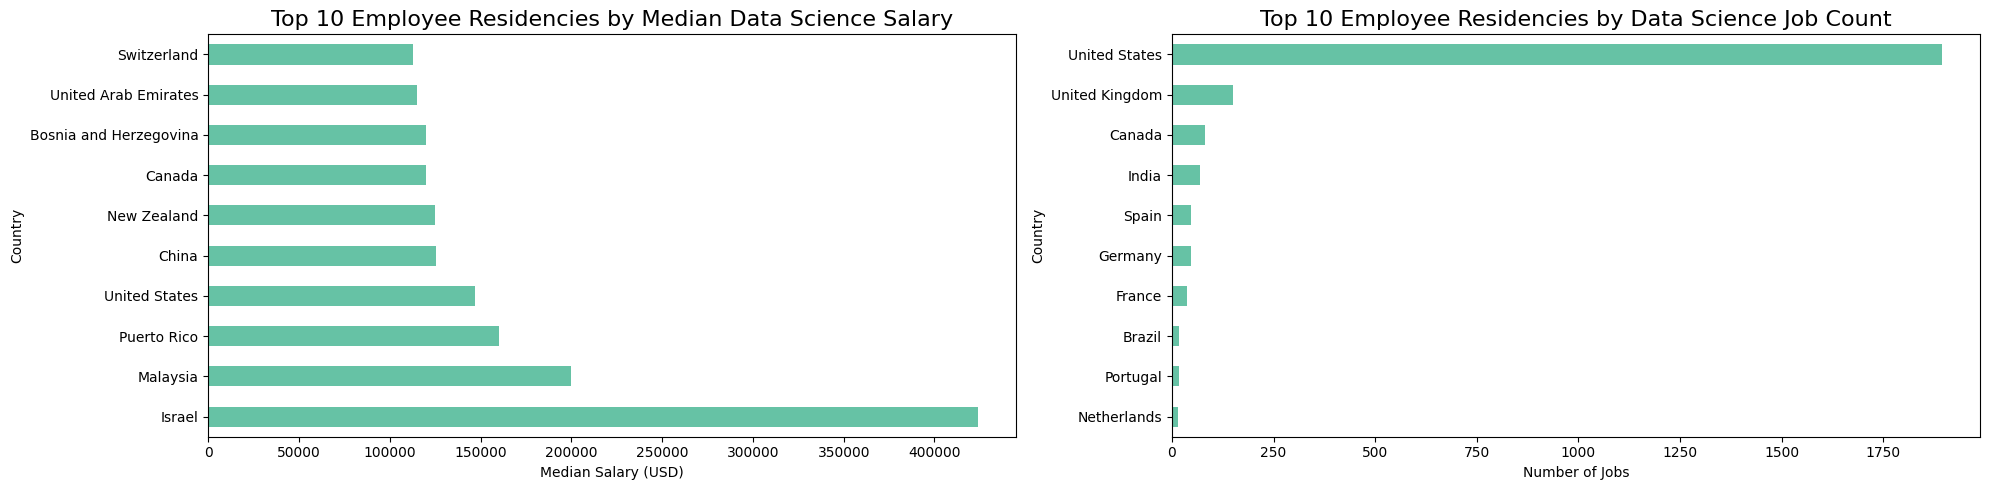

In [40]:
plt.figure(figsize=(20, 5))

# Plot 1: Top 10 countries by median salary
plt.subplot(1, 2, 1)
top_emp_residence.plot(kind='barh')
plt.ylabel('Country')
plt.xlabel('Median Salary (USD)')
plt.title('Top 10 Employee Residencies by Median Data Science Salary', fontsize=16)

# Plot 2: Top 10 countries by number of jobs
plt.subplot(1, 2, 2)
top_er.sort_values().plot(kind='barh')
plt.ylabel('Country')
plt.xlabel('Number of Jobs')
plt.title('Top 10 Employee Residencies by Data Science Job Count', fontsize=16)

plt.tight_layout()
plt.show()


*Top 10 Employee Residences by Median Data Science Salary*

**Insight:**

**Some countries pay very high salaries to data professionals even though they have fewer workers, indicating premium pay for scarce talent.**

*Top 10 Employee Residences by Data Science Job Count*


**Insight:**

**The United States has the highest concentration of data science jobs, while other countries have much smaller workforces.**

In [41]:
pd.crosstab(data['employee_residence'],data['salary_range'])

salary_range,<25K,25K-50K,50K–100K,100K–150K,150K–200K,200K+
employee_residence,,,,,,
Algeria,0,0,1,0,0,0
American Samoa,1,1,0,0,0,0
Argentina,2,3,1,0,0,0
Armenia,0,1,0,0,0,0
Australia,0,3,6,2,0,0
...,...,...,...,...,...,...
Ukraine,1,1,1,1,0,0
United Arab Emirates,0,0,1,2,0,0
United Kingdom,0,22,81,38,7,2


# **📊 Company Locations vs Remote Ratio vs Salary**

In [42]:
country_remote_salary=(
    data.groupby(['company_location','remote_ratio'])['salary']
    .median()
    .reset_index()
    .sort_values('salary')
)
top_countries=data['company_location'].value_counts().head(10).index

In [43]:
country_remote_salary=country_remote_salary[country_remote_salary['company_location'].isin(top_countries)]
country_remote_salary

,company_location,remote_ratio,salary
16,Brazil,On-site,15904.0
56,India,Remote,17022.0
54,India,Hybrid,22264.5
55,India,On-site,28209.5
104,Spain,Hybrid,31520.0
41,France,On-site,45618.5
94,Portugal,Remote,46076.5
105,Spain,On-site,47784.5
17,Brazil,Remote,48000.0
6,Australia,Hybrid,50000.0


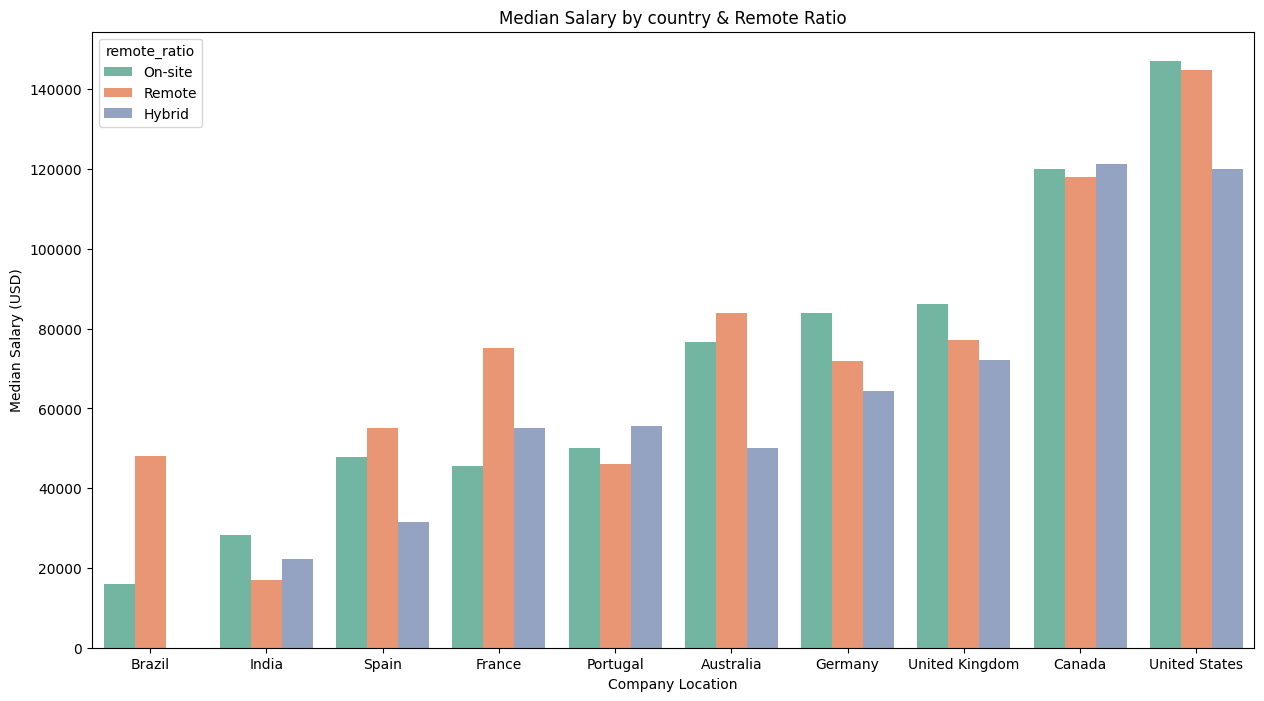

In [44]:
plt.figure(figsize=(15,8))
sns.barplot(
    data=country_remote_salary,
    x='company_location',
    y='salary',
    hue='remote_ratio'

)
plt.title('Median Salary by country & Remote Ratio')
plt.xlabel('Company Location')
plt.ylabel('Median Salary (USD)')
plt.show()

**Insight:**

**Salaries differ by country more than by work mode—high-paying countries like the United States and Canada offer strong salaries across all work types, while lower-paying countries show bigger differences between remote, hybrid, and on-site roles.**

# **📊 Experience vs Remote Ratio Vs Salary**

In [45]:
exp_remote_salary=(data.groupby(['experience_level','remote_ratio'])['salary']
                   .median()
                   .reset_index().sort_values('salary'))

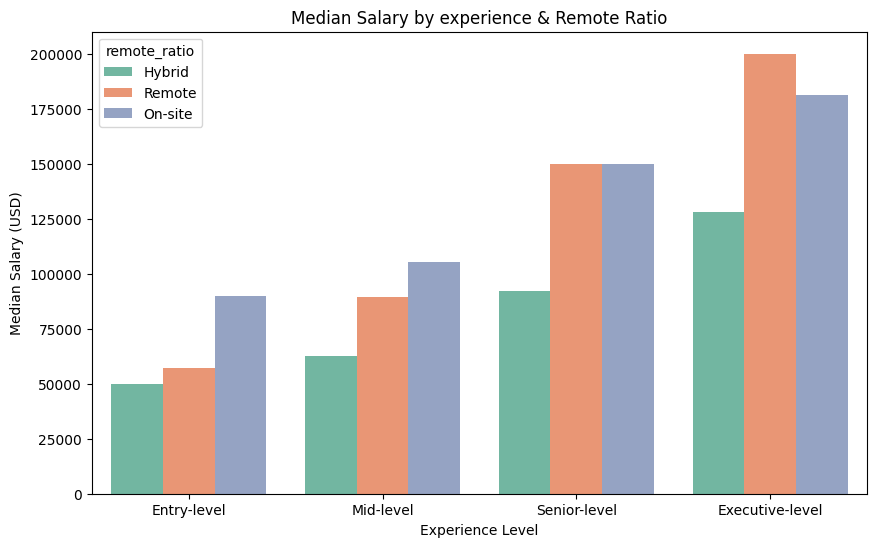

In [46]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=exp_remote_salary,
    x='experience_level',
    y='salary',
    hue='remote_ratio'

)
plt.title('Median Salary by experience & Remote Ratio')
plt.xlabel('Experience Level')
plt.ylabel('Median Salary (USD)')
plt.show()

**Insight:**

**Salary increases strongly with experience, and at every experience level, on-site generally pay more than remote roles and hybrid roles—especially at senior and executive levels.**

# **📊 Company size vs Experience vs Salary**

In [47]:
size_experience_salary = (
    data.groupby(['company_size', 'experience_level'])['salary']
    .median()
    .reset_index()
)

size_experience_salary


,company_size,experience_level,salary
0,Large,Entry-level,58551.0
1,Large,Executive-level,150000.0
2,Large,Mid-level,81264.0
3,Large,Senior-level,146350.0
4,Medium,Entry-level,70000.0
5,Medium,Executive-level,195800.0
6,Medium,Mid-level,100000.0
7,Medium,Senior-level,150000.0
8,Small,Entry-level,52008.0
9,Small,Executive-level,190000.0


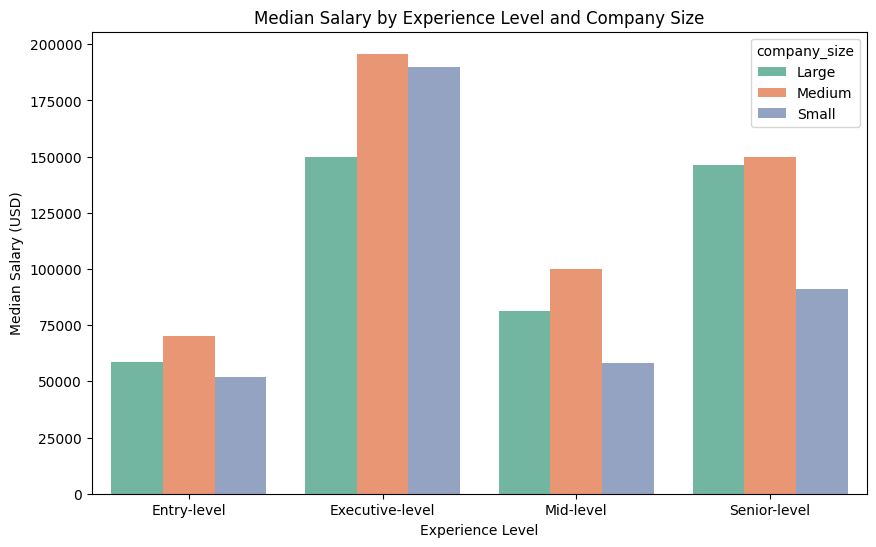

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=size_experience_salary,
    x='experience_level',
    y='salary',
    hue='company_size'
)

plt.title('Median Salary by Experience Level and Company Size')
plt.xlabel('Experience Level')
plt.ylabel('Median Salary (USD)')
plt.show()


**Insight:**

**Across all experience levels, medium-sized companies tend to pay the highest salaries, while entry-level roles are paid similarly across company sizes, and salary gaps widen significantly at senior and executive levels.**

# **📊 Company Size vs Remote Ratio vs Salary**

In [49]:
size_remote_salary = (
    data.groupby(['company_size', 'remote_ratio'])['salary']
    .median()
    .reset_index()
)

size_remote_salary

,company_size,remote_ratio,salary
0,Large,Hybrid,70069.0
1,Large,On-site,120402.0
2,Large,Remote,105000.0
3,Medium,Hybrid,50000.0
4,Medium,On-site,140000.0
5,Medium,Remote,137450.0
6,Small,Hybrid,62883.0
7,Small,On-site,54660.5
8,Small,Remote,60938.0


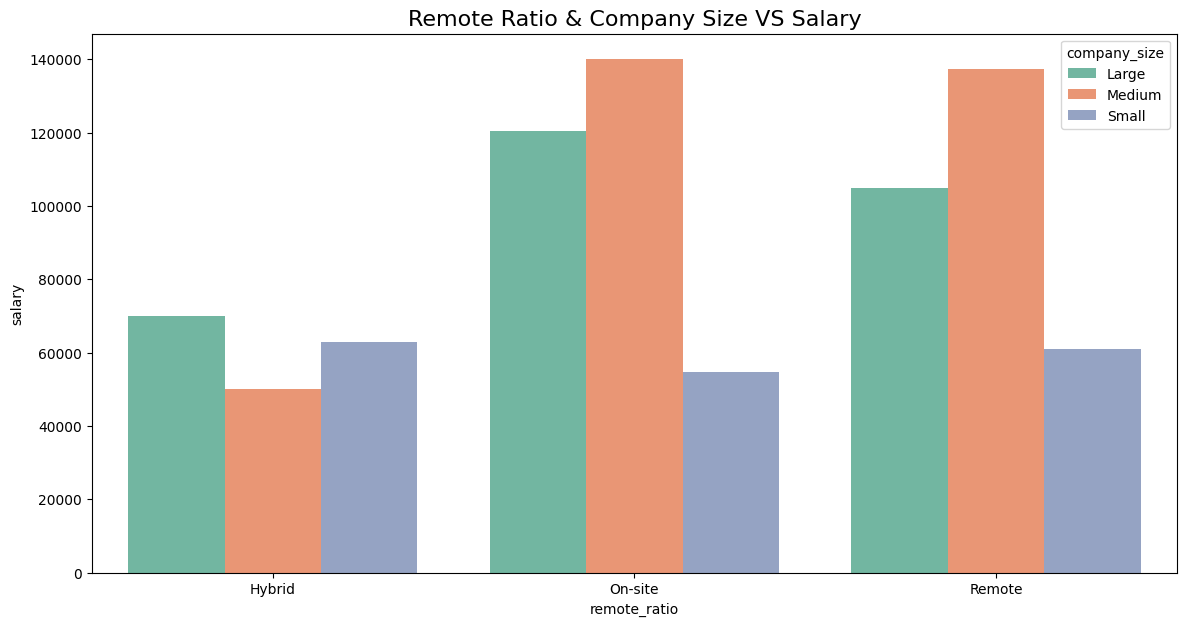

In [50]:
plt.figure(figsize=(14, 7))
sns.barplot(data=size_remote_salary, x='remote_ratio', y='salary', hue='company_size')
plt.title('Remote Ratio & Company Size VS Salary', fontdict={'fontsize': 16})
plt.show()

**Insight:**

**Medium-sized companies pay the highest salaries for both remote and on-site roles, while small companies consistently offer lower pay regardless of work mode, and large companies fall in between.**

# **📊 Demand vs Pay By Job Role**

In [51]:
role_demand = data['job_title'].value_counts().head(10)

role_pay = (
    data.groupby('job_title')['salary']
    .median()
)

demand_vs_pay = (
    role_demand.to_frame('job_count')
    .join(role_pay)
    .reset_index()
    .rename(columns={'index': 'job_title'})
)

demand_vs_pay


,job_title,job_count,salary
0,Data Engineer,598,135000.0
1,Data Scientist,538,132600.0
2,Data Analyst,396,102920.0
3,Machine Learning Engineer,206,145000.0
4,Analytics Engineer,91,143860.0
5,Research Scientist,65,145900.0
6,Data Architect,64,163750.0
7,Data Science Manager,52,175100.0
8,ML Engineer,34,160000.0
9,Research Engineer,33,155000.0


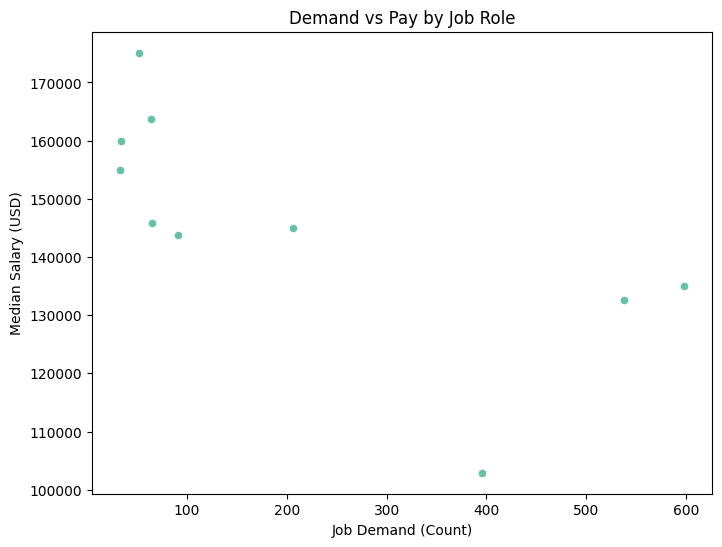

In [52]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=demand_vs_pay,
    x='job_count',
    y='salary'
)

plt.title('Demand vs Pay by Job Role')
plt.xlabel('Job Demand (Count)')
plt.ylabel('Median Salary (USD)')
plt.show()

**Insight:**

**Jobs that pay the highest are usually specialized leadership roles with fewer openings, while roles with many job opportunities tend to offer moderate salaries—showing that high demand doesn’t always mean high pay.**

#**Final Conclusion**

**The data shows that experience, role seniority, company size, and work type strongly influence salary.
Higher pay is mostly driven by senior/executive roles, specialized job titles, and medium-to-large companies, while job demand is highest for mid-level roles with moderate pay.
Remote and on-site jobs generally offer better salaries than hybrid, and countries like the United States dominate in job availability, whereas some countries offer very high pay but limited opportunities.**